<a href="https://colab.research.google.com/github/sid2904/cs666student/blob/main/Copy_of_CS666_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

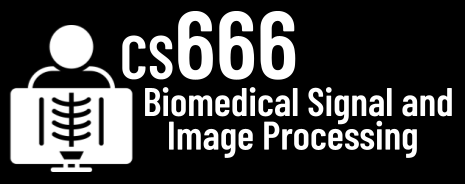
#Assignment 2

In [1]:
### TODO: YOUR NAME: Siddhant Setia

In [39]:
%pylab inline
import os
import pandas as pd

Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['sample', 'psd']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [2]:
# we will be using the EEG/MEG analysis library MNE
# documentation is available here: https://mne.tools/stable/index.html
!pip install -U mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 50.0 MB/s eta 0:00:00


In [3]:
import mne # let's import MNE

# .. and the sample dataset
from mne.datasets import sample

# These data were acquired with the Neuromag Vectorview system at
# MGH/HMS/MIT Athinoula A. Martinos Center Biomedical Imaging.
# EEG data from an electrode cap was acquired simultaneously with the MEG.

### EXPERIMENT DESCRIPTION ###
# In this experiment, checkerboard patterns were presented to the subject into
# the left and right visual field, interspersed by tones to the left or right ear.
# The interval between the stimuli was 750 ms. Occasionally a smiley face was
# presented at the center of the visual field. The subject was asked to press a
# key with the right index finger as soon as possible after the appearance of the face.

In [4]:
# and let's load it!
data_path = sample.data_path()
raw = mne.io.read_raw_fif(os.path.join(data_path,'MEG/sample/sample_audvis_raw.fif'))

Using default location ~/mne_data for sample...
Creating /root/mne_data


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of '/root/mne_data/MNE-sample-data-processed.tar.gz' to '/root/mne_data'


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 02m23s (1576.2 MB)
Opening raw data file /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.


**Task 1:** Analyze the data. [20 Points]


In [5]:
# How many EEG channels were used when acquiring the data?
# Hint: You can use raw.info or raw.ch_names to figure this out!
# TODO: YOUR ANSWER

In [6]:
raw.info

# Answer: 60 Channels

<Info | 21 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 description: acquisition (megacq) VectorView system at NMR-MGH
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 172.2 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 proj_id: 1
 proj_name: test
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off
 sfreq: 600.6 Hz
>

In [7]:
# TODO What is the sampling frequency of this data?
# TODO: YOUR ANSWER

In [8]:
# Answer: 600.61 Hz

raw.info['sfreq']

600.614990234375

In [9]:
# TODO What is the total duration of the measurement?
# TODO: YOUR ANSWER

In [10]:
# Answer:277.71 seconds

num_samples = len(raw)

print(num_samples/raw.info['sfreq'])

277.7153462901591


**Task 2:** Let's look at some channels! [20 Points]

Using matplotlib as 2D backend.


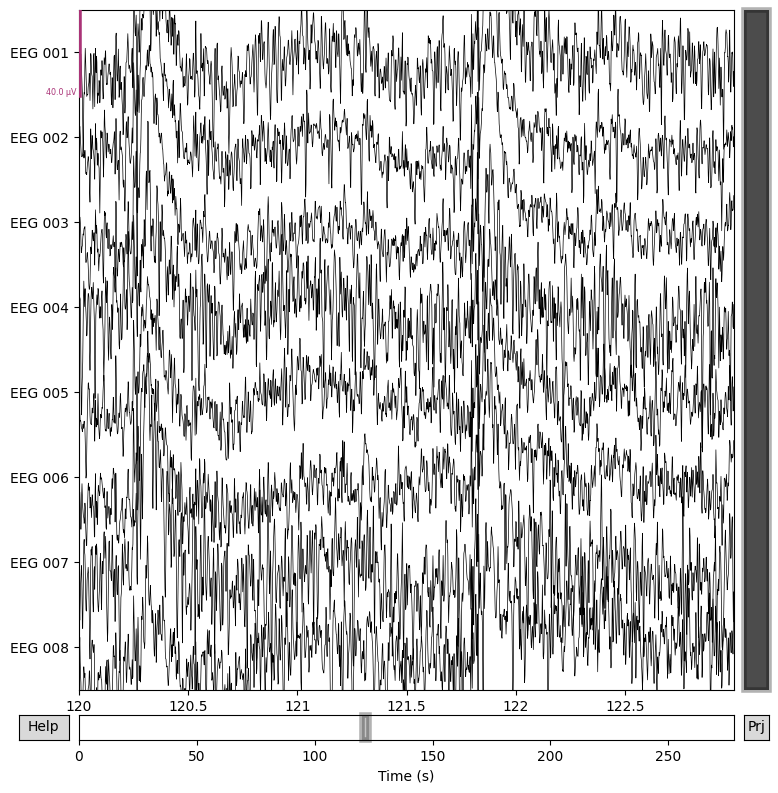

In [11]:
# the code below plots EEG channels 1-8 for 3 seconds after 2 minutes
chs = ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008']
chan_idxs = [raw.ch_names.index(ch) for ch in chs]
ecg1to8 = raw.plot(order=chan_idxs, start=120, duration=3)

In [12]:
# TODO please plot EEG channels 50-60 for 1 second after 151 seconds.

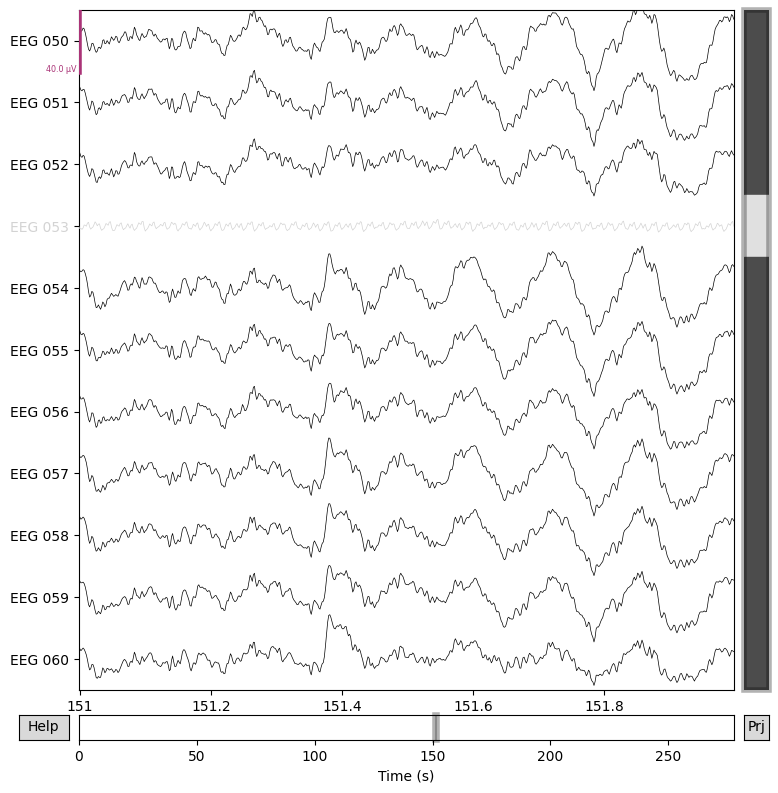

In [13]:
chs = ['EEG 0'+str(i) for i in range(50, 61)]
chan_idxs = [raw.ch_names.index(ch) for ch in chs]
ecg50to60 = raw.plot(order=chan_idxs, start=151, duration=1)

In [14]:
# TODO: Do you see a bad channel? If yes, which one?
# TODO: YOUR_ANSWER

In [15]:
# Answer: Yes, Channel EEG 053

In [16]:
# TODO: Please calculate the maximum value of the bad channel and compare it
# against a good channel. How would you detect a bad channel programmatically?
# Hint: See https://mne.tools/dev/generated/mne.io.Raw.html#mne.io.Raw to access
#       individual channels

In [17]:
bad_channel_data = raw.get_data(picks=["EEG 053"])[0]
bad_channel_max = np.max(np.abs(bad_channel_data))
print(f"EEG 053 (Bad) absolute max = {bad_channel_max:.8f}")

good_channel_data = raw.get_data(picks=["EEG 052"])[0]
good_channel_max = np.max(np.abs(good_channel_data))
print(f"EEG 052 (Good) absolute max = {good_channel_max:.8f}")

EEG 053 (Bad) absolute max = 0.00006101
EEG 052 (Good) absolute max = 0.00015742


In [75]:
# To detect bad channels we can use find_bad_channels_lof function and provide appropriate thresholds. Here we get: ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 007', 'EEG 008', 'EEG 015']

raw.load_data()

raw_f = raw.copy().filter(1., 40.)

bad_chs = mne.preprocessing.find_bad_channels_lof(
    raw_f,
    picks="eeg",
    n_neighbors=20,
    threshold=1.2
)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)

LOF: Detected bad channel(s): ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 007', 'EEG 008', 'EEG 015']


**Task 3:** How long between event and brain activity? [25 Points]

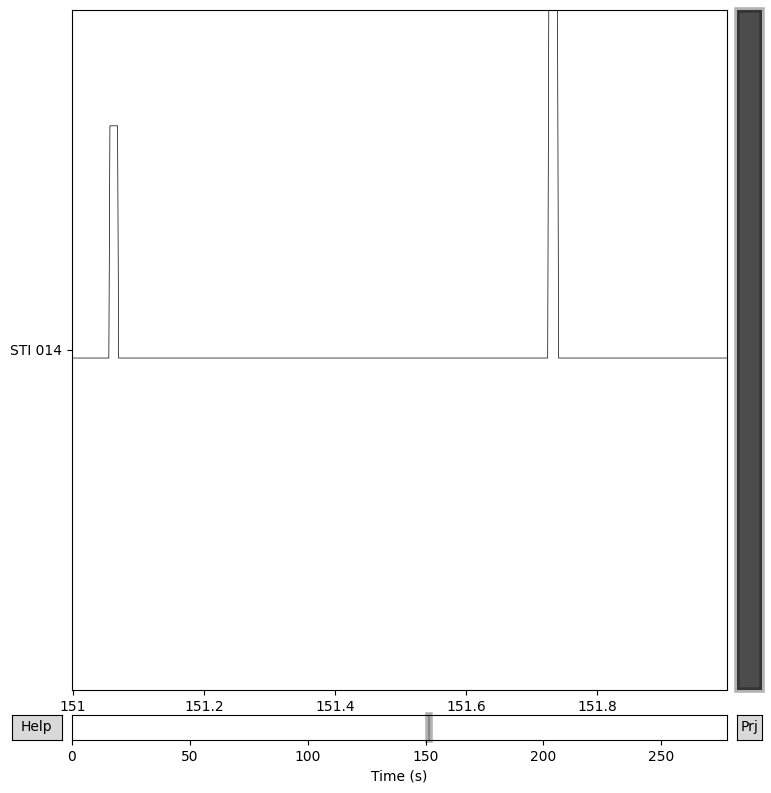

In [45]:
# the following code plots the stimulus channel for the same time
chan_idxs = [raw.ch_names.index('STI 014')]
stim = raw.plot(order=chan_idxs, start=151, duration=1)

In [46]:
# TODO Please combine the last two plots into one.
# the plot should show EEG channels 50-60 and the stimulus channel together.

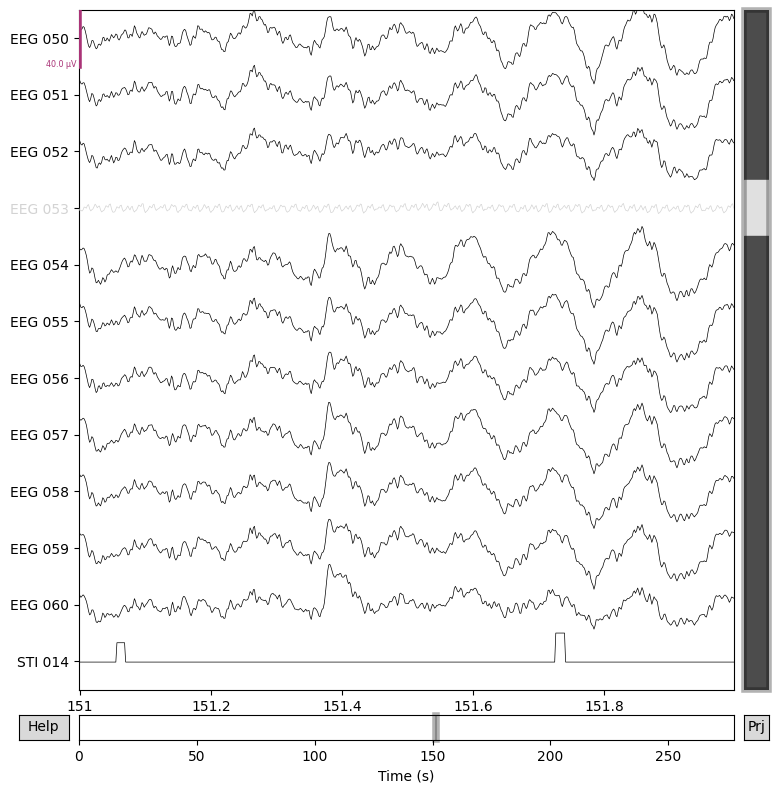

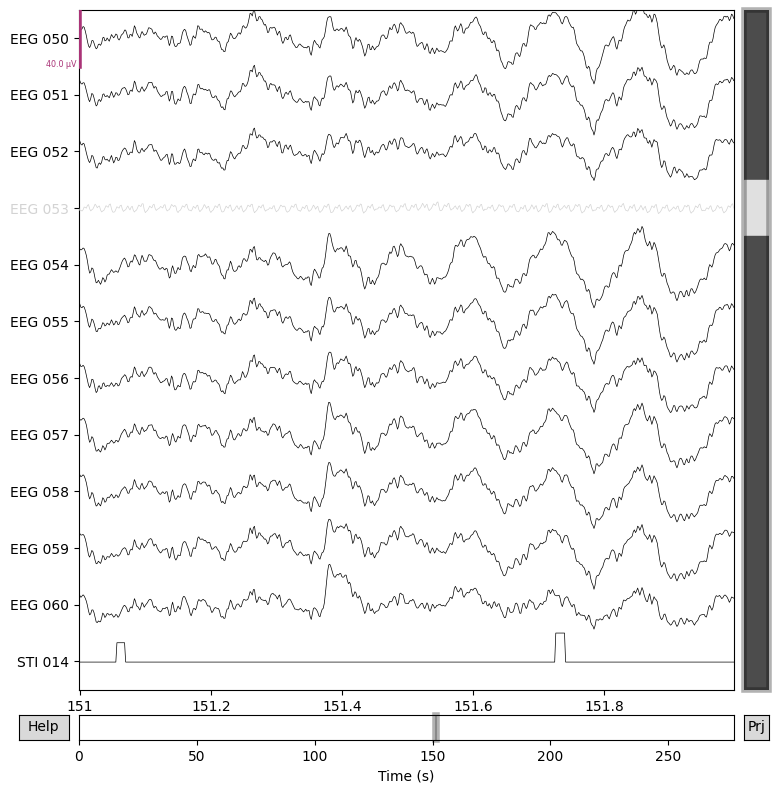

In [47]:
chs = ['EEG 0' + str(i) for i in range(50, 61)]
eeg_idxs = [raw.ch_names.index(ch) for ch in chs]

stim_idx = raw.ch_names.index('STI 014')

combined_idxs = eeg_idxs + [stim_idx]

raw.plot(order=combined_idxs, start=151, duration=1)

In [48]:
# TODO How many stimulus events do you observe?
# TODO: YOUR_ANSWER

In [49]:
# Answer: There are 2 stimulus events for STI 014

In [50]:
# TODO Please estimate the time between the first stimulus and brain activity response.
# TODO: YOUR_ANSWER

In [56]:
events = mne.find_events(raw, stim_channel="STI 014")
sfreq = raw.info["sfreq"]

first_event = events[0, 0]

t0 = (first_event - raw.first_samp) / sfreq
print(f"First stimulus at t = {t0}")

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
First stimulus at t = 3.6246181587150867


In [57]:
raw_eeg = raw.copy().pick("eeg")
# raw_eeg.load_data()
raw_eeg.filter(0.1, 30., fir_design="firwin")

epochs = mne.Epochs(
    raw_eeg,
    events,
    tmin=-0.2,
    tmax=0.5,
    baseline=(-0.2, 0.0),
    # preload=True,
    reject_by_annotation=True
)

evoked = epochs.average()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 19821 samples (33.001 s)

Not setting metadata
320 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 320 events and 421 original time points ...
0 bad epochs dropped


In [60]:
_, lat = evoked.get_peak(
    ch_type="eeg",
    tmin=0.05,
    tmax=0.25,
    mode="pos"
)

print(f"Time between the first stimulus and brain activity response: {lat*1e3:.1f} ms")

Time between the first stimulus and brain activity response: 89.9 ms


**Task 4:** Localize different brain waves for different stimuli! [35 Points]

In [ ]:
# the following code groups all stimuli together
# and allows the visualization of average brain activity per stimuli.
events = mne.find_events(raw, stim_channel='STI 014')
event_dict = {'auditory/left': 1,
              'auditory/right': 2,
              'visual/left': 3,
              'visual/right': 4,
              'face': 5,
              'button': 32}

picks = mne.pick_types(raw.info, eeg=True)

epochs = mne.Epochs(raw, events, event_id=event_dict, picks=picks,
                    preload=True)

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Not setting metadata
320 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Loading data for 320 events and 421 original time points ...
0 bad epochs dropped


    Using multitaper spectrum estimation with 7 DPSS windows


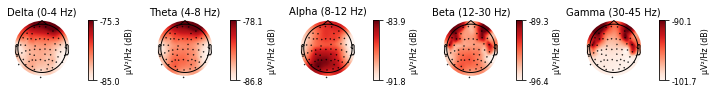

In [ ]:
# here we see the average localized brain activity for the right visual stimuli
visual_activity = epochs['visual/right'].plot_psd_topomap()

    Using multitaper spectrum estimation with 7 DPSS windows


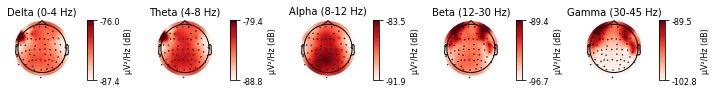

In [ ]:
# here we see the average localized brain activity for the shown 'face'
face_activity = epochs['face'].plot_psd_topomap()

In [ ]:
# TODO The above plots use a deprecated API call. Please re-create both plots here with the newer API.

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


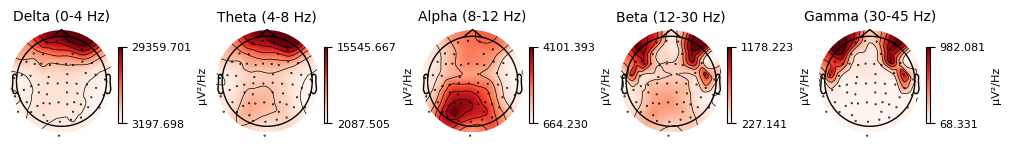

In [ ]:
visual_activity = epochs['visual/right'].compute_psd().plot_topomap()

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


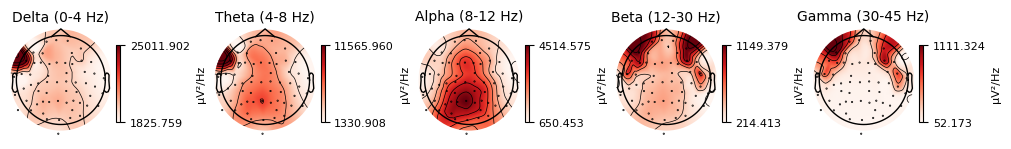

In [ ]:
face_activity = epochs['face'].compute_psd().plot_topomap()

In [ ]:
# TODO Now compare the two old plots with the new ones. What are the differences?
# TODO: YOUR ANSWER

In [ ]:
# The new plots use different unit of measurement.
# The new plots compute the average value across epochs for plotting.

In [ ]:
# TODO Please visualize the average brain activity when the subject pushes the button

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


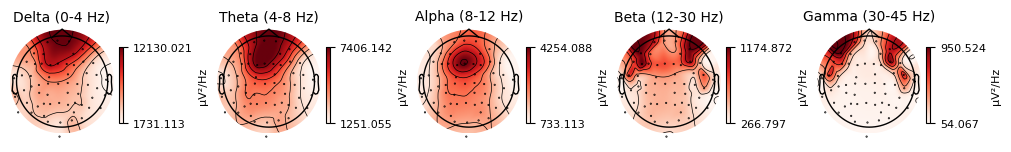

In [ ]:
visual_activity = epochs['button'].compute_psd().plot_topomap()

In [ ]:
# TODO Which difference do you see between the visual/right, the face, and the button event?
# TODO Which brain region seems active during the button event?
# Hint: visual/right and face seem more similar to the button event. Think about why?
# TODO: YOUR ANSWER

In [ ]:
# The main difference is in alpha where stronger involvement of posterior area is present in visual/right and face, however button has more front involvement.
# Center scalp area seems more active during button event. visual/right and face seem more similar to the button event because they are both visual stimuli.

**Bonus Task:** What type of event happened in Task 3? [33 Points]

In [ ]:
# TODO Please go back to Task 3. Can you figure out which event types happened?

In [73]:
sfreq = raw.info["sfreq"]

event_times = (events[:, 0] - raw.first_samp) / sfreq

mask = (event_times >= 151) & (event_times <= 152)
event_types = events[mask][:, 2]

event_dict = {'auditory/left': 1,
              'auditory/right': 2,
              'visual/left': 3,
              'visual/right': 4,
              'face': 5,
              'button': 32}
event_dict_rev = {v: k for k, v in event_dict.items()}

In [74]:
for event_typ in event_types:
  print(f"{event_dict_rev.get(event_typ)}")

auditory/right
visual/left


In [ ]:
# Answer: So, we can say the 2 events which happened were: auditory/right and visual/left.

In [ ]:
# You did it!!
#
# ┈┈┈┈┈┈▕▔╲
# ┈┈┈┈┈┈┈▏▕
# ┈┈┈┈┈┈┈▏▕▂▂▂
# ▂▂▂▂▂▂╱┈▕▂▂▂▏
# ▉▉▉▉▉┈┈┈▕▂▂▂▏
# ▉▉▉▉▉┈┈┈▕▂▂▂▏
# ▔▔▔▔▔▔╲▂▕▂▂|
#